# DeepPeak validation analysis

This notebook trains and validates one WaveNet against a literal fixed-threshold baseline. Its notebook-local `ValidationAnalysis` class keeps the working cells concise while leaving every scientific choice visible.

## 1. Imports and reproducible setup

In [ ]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from scipy.optimize import linear_sum_assignment
from scipy.signal import find_peaks

from DeepPeak import UniformCount
from DeepPeak.benchmarking import BenchmarkCase
from DeepPeak.generation import Gaussian, PoissonCount, SignalGenerator
from DeepPeak.models import TrainingConfig, WaveNet, smooth_bce

REPO_ROOT = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / "DeepPeak" / "weights").exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError("Could not locate the DeepPeak repository root.")

OUTPUT_DIR = REPO_ROOT / "showcase" / "webinar" / "validation_outputs"
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 240,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 2. Load a saved WaveNet

Set `LOAD_SAVED_WAVENET` to `False` only when you want to start from a new model.

In [ ]:
NOTEBOOK_DIRECTORY = REPO_ROOT / "notebooks"
MODEL_DIRECTORY = NOTEBOOK_DIRECTORY / "trained_wavenet"
LOAD_SAVED_WAVENET = True

wavenet = None
MODEL_LOADED = False
if LOAD_SAVED_WAVENET and (MODEL_DIRECTORY / "config.json").exists():
    wavenet = WaveNet.load(str(MODEL_DIRECTORY))
    MODEL_LOADED = True
    print(f"Loaded WaveNet from {MODEL_DIRECTORY}")
elif LOAD_SAVED_WAVENET:
    print(f"No saved WaveNet found at {MODEL_DIRECTORY}; a new model will be trained.")

### Notebook-local analysis workflow

For now, the complete validation workflow is defined here rather than in the DeepPeak package. Collapse this cell during normal use.

In [ ]:
class ValidationAnalysis:
    """Generate, train, evaluate, and visualize one validation experiment."""

    METRIC_SPECS = (
        ("precision", "Precision"),
        ("recall", "Recall"),
        ("count_bias_percent", "Signed count bias (%)"),
        ("timing_error_samples", "Timing error (samples)"),
        ("amplitude_error", "Amplitude error"),
        ("throughput_traces_per_second", "Throughput (traces/s)"),
    )

    def __init__(
        self, *, kernel, model=None, sequence_length=512,
        event_counts=tuple(range(1, 11)), train_samples=7400,
        blank_training_samples=500,
        test_traces_per_density=24, validation_fraction=0.2,
        train_seed=1729, test_seed=2718, acquisition=None,
        cnn_threshold=0.5, classical_threshold_fraction=0.5,
        minimum_event_amplitude=1.0, classical_debounce_samples=3,
        minimum_cnn_distance=5, match_tolerance=5, 
        target_width=5.0,
        target_min_peak_amplitude=0.03, output_dir=None,
    ):
        self.kernel = kernel
        self.model = model
        self.sequence_length = int(sequence_length)
        self.event_counts = tuple(int(value) for value in event_counts)
        self.train_samples = int(train_samples)
        self.blank_training_samples = int(blank_training_samples)
        self.test_traces_per_density = int(test_traces_per_density)
        self.validation_fraction = float(validation_fraction)
        self.train_seed = int(train_seed)
        self.test_seed = int(test_seed)
        self.acquisition = dict(acquisition or {})
        self.cnn_threshold = float(cnn_threshold)
        self.classical_threshold_fraction = float(classical_threshold_fraction)
        self.minimum_event_amplitude = float(minimum_event_amplitude)
        self.classical_debounce_samples = int(classical_debounce_samples)
        if self.classical_debounce_samples < 1:
            raise ValueError("classical_debounce_samples must be at least 1")
        self.minimum_cnn_distance = int(minimum_cnn_distance)
        self.match_tolerance = int(match_tolerance)
        self.target_width = float(target_width)
        self.target_min_peak_amplitude = float(target_min_peak_amplitude)
        self.output_dir = Path(output_dir) if output_dir is not None else None
        if self.output_dir is not None:
            self.output_dir.mkdir(parents=True, exist_ok=True)
        self.full_training_dataset = None
        self.training_dataset = None
        self.validation_dataset = None
        self.test_dataset = None
        self.cases = []
        self.history = None
        self.results = None

    @property
    def density_levels(self):
        return tuple(float(value) for value in self.event_counts)

    def prepare_datasets(self):
        training_generator = SignalGenerator(self.sequence_length)
        training_seeds = np.random.default_rng(self.train_seed)
        maximum_count = max(self.event_counts)
        training_generator.add_to_set(
            n_samples=self.train_samples,
            kernel=self.kernel,
            peak_count=PoissonCount(
                bounds=(0, maximum_count), rate=(0, maximum_count)
            ),
            seed=int(training_seeds.integers(0, 2**32 - 1)),
            **self.acquisition,
        )
        training_generator.add_to_set(
            n_samples=self.blank_training_samples,
            kernel=self.kernel,
            peak_count=PoissonCount(bounds=(0, 0), rate=0),
            seed=int(training_seeds.integers(0, 2**32 - 1)),
            **self.acquisition,
        )
        self.full_training_dataset = training_generator.dataset().shuffle(
            seed=self.train_seed
        )
        self.training_dataset, self.validation_dataset = (
            self.full_training_dataset.train_test_split(
                test_size=self.validation_fraction,
                shuffle=False,
            )
        )

        test_generator = SignalGenerator(self.sequence_length)
        test_seeds = np.random.default_rng(self.test_seed)
        for event_count in self.event_counts:
            test_generator.add_to_set(
                n_samples=self.test_traces_per_density,
                kernel=self.kernel,
                peak_count=UniformCount(bounds=(event_count, event_count)),
                seed=int(test_seeds.integers(0, 2**32 - 1)),
                **self.acquisition,
            )
        self.test_dataset = test_generator.dataset().shuffle(seed=self.test_seed)
        self.cases = self._to_benchmark_cases(self.test_dataset)
        self.results = None
        return self

    def density_counts(self):
        self._require_datasets()
        datasets = {
            "full_training": self.full_training_dataset,
            "training": self.training_dataset,
            "validation": self.validation_dataset,
            "test": self.test_dataset,
        }
        frame = pd.DataFrame({
            name: pd.Series(self._event_counts(dataset)).value_counts()
            for name, dataset in datasets.items()
        }).reindex((0, *self.event_counts)).fillna(0).astype(int)
        frame.index.name = "events_per_trace"
        return frame

    def plot_dataset(
        self, dataset="training", *, number_of_samples=6,
        number_of_columns=3, randomize_signal=False, show_targets=True,
    ):
        self._require_datasets()
        choices = {
            "full_training": self.full_training_dataset,
            "training": self.training_dataset,
            "validation": self.validation_dataset,
            "test": self.test_dataset,
        }
        if dataset not in choices:
            raise ValueError(f"dataset must be one of {sorted(choices)}")
        selected = choices[dataset]
        return selected.plot(
            number_of_samples=number_of_samples,
            number_of_columns=number_of_columns,
            randomize_signal=randomize_signal,
            reference_pulse_trace=self._targets(selected) if show_targets else None,
        )

    def plot_density(
        self, event_count, *, number_of_samples=3, number_of_columns=3,
        randomize_signal=False, show_targets=True,
    ):
        self._require_datasets()
        dataset = self.full_training_dataset
        available = np.flatnonzero(
            self._event_counts(dataset) == int(event_count)
        )
        if not available.size:
            raise ValueError(f"No training traces contain {event_count} events")
        count = min(number_of_samples, available.size)
        if randomize_signal:
            indices = np.random.default_rng().choice(
                available, size=count, replace=False
            )
        else:
            indices = available[:count]
        targets = self._targets(dataset)
        rows = int(np.ceil(count / number_of_columns))
        figure, axes = plt.subplots(
            rows, number_of_columns, figsize=(5 * number_of_columns, 2.7 * rows),
            squeeze=False, sharex=True,
        )
        for axis, index in zip(axes.ravel(), indices):
            signal = dataset.signals[index]
            axis.plot(dataset.x_values, signal, color="#1f7775", linewidth=1.0)
            if show_targets:
                target = targets[index]
                if target.max() > 0:
                    target = target / target.max() * signal.max()
                axis.plot(
                    dataset.x_values, target, color="#e46b5d",
                    linewidth=1.2, linestyle="--",
                )
            axis.set_title(f"Trace {index}")
            axis.grid(alpha=0.2)
        for axis in axes.ravel()[count:]:
            axis.set_visible(False)
        figure.tight_layout()
        return figure

    def fit(self, config, save_name="trained_wavenet"):
        self._require_datasets()
        if not np.isclose(config.validation_split, self.validation_fraction):
            raise ValueError(
                "TrainingConfig.validation_split must match "
                "ValidationAnalysis.validation_fraction"
            )
        self.history = self.model.fit_dataset(
            self.full_training_dataset,
            target=self._targets(self.full_training_dataset),
            normalization="zscore",
            config=config,
        )
        if save_name is not None:
            self.model.save(str(self.output_dir / save_name))
        return self.history

    def classical_detect(self, signal, threshold_fraction=None):
        values = np.asarray(signal, dtype=np.float32).ravel()
        baseline_removed = values - np.median(values)
        fraction = (
            self.classical_threshold_fraction
            if threshold_fraction is None else float(threshold_fraction)
        )
        level = fraction * self.minimum_event_amplitude
        above = baseline_removed >= level
        transitions = np.diff(np.pad(above.astype(np.int8), (1, 1)))
        starts = np.flatnonzero(transitions == 1)
        stops = np.flatnonzero(transitions == -1)
        stable_regions = [
            (start, stop)
            for start, stop in zip(starts, stops)
            if stop - start >= self.classical_debounce_samples
        ]
        return np.asarray([
            start + np.argmax(baseline_removed[start:stop])
            for start, stop in stable_regions
        ], dtype=np.int64)

    def cnn_output(self, signal):
        values = np.asarray(signal, dtype=np.float32).ravel()
        normalized = (values - values.mean()) / (values.std() + 1e-8)
        return np.asarray(
            self.model.predict(normalized[None, ..., None], verbose=0)
        ).squeeze()

    def cnn_detect(self, signal):
        peaks, _ = find_peaks(
            self.cnn_output(signal),
            height=self.cnn_threshold,
            distance=self.minimum_cnn_distance,
        )
        return peaks.astype(np.int64)

    def calibrate_cnn_threshold(self, thresholds=None):
        """Select the validation threshold with the best event-level F1 score."""
        thresholds = (
            np.linspace(0.05, 0.95, 19)
            if thresholds is None else np.asarray(thresholds, dtype=float)
        )
        inputs = self.validation_dataset.to_model_inputs(
            normalization="zscore"
        ).astype(np.float32)
        probabilities = np.asarray(
            self.model.predict(inputs, verbose=0)
        ).squeeze(-1)
        cases = self._to_benchmark_cases(self.validation_dataset)
        rows = []
        for threshold in thresholds:
            tp = fp = fn = 0
            count_biases = []
            for case, probability in zip(cases, probabilities):
                predicted, _ = find_peaks(
                    probability, height=threshold,
                    distance=self.minimum_cnn_distance,
                )
                truth_rows, _ = self._match_events(case.peak_indices, predicted)
                matches = len(truth_rows)
                tp += matches
                fp += len(predicted) - matches
                fn += len(case.peak_indices) - matches
                count_biases.append(
                    (len(predicted) - len(case.peak_indices))
                    / max(len(case.peak_indices), 1)
                )
            precision = tp / max(tp + fp, 1)
            recall = tp / max(tp + fn, 1)
            f1 = 2 * precision * recall / max(precision + recall, 1e-12)
            rows.append({
                "threshold": float(threshold),
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "count_bias_percent": 100 * float(np.mean(count_biases)),
            })
        scan = pd.DataFrame(rows)
        scan["absolute_count_bias_percent"] = scan["count_bias_percent"].abs()
        best = scan.sort_values(
            ["f1", "absolute_count_bias_percent"],
            ascending=[False, True],
        ).iloc[0]
        self.cnn_threshold = float(best["threshold"])
        return scan

    def evaluate(self):
        self._require_datasets()
        detectors = {
            "Classical baseline": self.classical_detect,
            "DeepPeak WaveNet": self.cnn_detect,
        }
        self.results = pd.concat([
            self._evaluate_detector(name, detector)
            for name, detector in detectors.items()
        ], ignore_index=True)
        self.results.to_csv(
            self.output_dir / "event_metrics_by_condition.csv", index=False
        )
        return self.results

    def summary(self):
        columns = [column for column, _ in self.METRIC_SPECS]
        summary = self.results.groupby("method")[columns].mean().round(3)
        summary.to_csv(self.output_dir / "event_metrics_summary.csv")
        return summary

    def plot_detector_comparison(self, index="random", event_count=None):
        level = float(max(self.event_counts) if event_count is None else event_count)
        candidates = [case for case in self.cases if case.level == level]
        if index == "random":
            index = int(np.random.default_rng().integers(len(candidates)))
        elif not isinstance(index, (int, np.integer)):
            raise TypeError('index must be an integer or "random"')
        if not -len(candidates) <= index < len(candidates):
            raise IndexError("diagnostic index is out of range")
        case = candidates[index]
        raw_trace = np.asarray(case.signal, dtype=np.float32)
        probability = self.cnn_output(raw_trace)
        cnn_peaks = self.cnn_detect(raw_trace)
        classical_peaks = self.classical_detect(raw_trace)
        cnn_scores = self._confusion_counts(case.peak_indices, cnn_peaks)
        classical_scores = self._confusion_counts(
            case.peak_indices, classical_peaks
        )
        sample_axis = np.arange(raw_trace.size)
        classical_baseline = np.median(raw_trace)
        classical_level = classical_baseline + (
            self.classical_threshold_fraction * self.minimum_event_amplitude
        )
        figure, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

        # Standard threshold detector, shown on the raw trace.
        axes[0].plot(
            sample_axis, raw_trace, color="#1f7775", linewidth=1.0,
            label="Raw detector trace",
        )
        axes[0].scatter(
            case.peak_indices, raw_trace[case.peak_indices], color="#e46b5d",
            s=22, label="Ground-truth events", zorder=3,
        )
        axes[0].scatter(
            classical_peaks, raw_trace[classical_peaks], color="#6b7280",
            marker="x", s=48, linewidths=1.5,
            label="Classical detections", zorder=4,
        )
        axes[0].axhline(
            classical_level, color="#6b7280", linestyle="--", linewidth=1.1,
            label=(
                f"Threshold = {self.classical_threshold_fraction:.0%} of min. amplitude"
            ),
        )
        axes[0].set_ylabel("Signal")
        axes[0].set_title(
            f"Classical threshold baseline — {self._format_scores(classical_scores)}"
        )
        axes[0].legend(loc="upper right", ncol=2, frameon=False)

        # WaveNet detector: raw trace on the left axis, probability on the right.
        axes[1].plot(
            sample_axis, raw_trace, color="#1f7775", linewidth=1.0,
            label="Raw detector trace",
        )
        axes[1].scatter(
            case.peak_indices, raw_trace[case.peak_indices], color="#e46b5d",
            s=22, label="Ground-truth events", zorder=3,
        )
        axes[1].scatter(
            cnn_peaks, raw_trace[cnn_peaks], facecolors="none",
            edgecolors="#1f3f5b", s=48, label="CNN detections", zorder=4,
        )
        score_axis = axes[1].twinx()
        score_axis.plot(
            sample_axis, probability, color="#1f3f5b", linewidth=1.1,
            label="CNN output",
        )
        score_axis.axhline(
            self.cnn_threshold, color="#e46b5d", linestyle="--", linewidth=1.1,
            label=f"CNN threshold = {self.cnn_threshold:.2f}",
        )
        score_axis.set_ylabel("CNN output", color="#1f3f5b")
        score_axis.tick_params(axis="y", labelcolor="#1f3f5b")
        score_axis.set_ylim(-0.05, 1.05)
        axes[1].set_ylabel("Signal")
        axes[1].set_xlabel("Sample index")
        axes[1].set_title(f"DeepPeak WaveNet — {self._format_scores(cnn_scores)}")
        handles, labels = axes[1].get_legend_handles_labels()
        score_handles, score_labels = score_axis.get_legend_handles_labels()
        axes[1].legend(
            handles + score_handles, labels + score_labels,
            loc="upper right", ncol=2, frameon=False,
        )
        for axis in axes:
            axis.grid(alpha=0.2)
        figure.suptitle(
            f"Detector comparison — trace {index % len(candidates)}, "
            f"{len(case.peak_indices)} ground-truth events"
        )
        figure.tight_layout(rect=(0, 0, 1, 0.95))
        figure.savefig(
            self.output_dir / "cnn_trace_diagnostic.png", bbox_inches="tight"
        )
        return figure

    def plot_metrics(self):
        figures = {}
        for column, ylabel in self.METRIC_SPECS:
            figure, axis = plt.subplots(figsize=(7, 4))
            for method, method_data in self.results.groupby("method"):
                axis.plot(
                    method_data["level"], method_data[column],
                    marker="o", linewidth=2, label=method,
                )
            axis.set_title(f"{ylabel} across matched event densities")
            axis.set_xlabel("Events per trace")
            axis.set_xticks(
                self.density_levels, [str(value) for value in self.event_counts]
            )
            axis.set_ylabel(ylabel)
            axis.grid(alpha=0.2)
            axis.legend(frameon=False)
            figure.tight_layout()
            figure.savefig(self.output_dir / f"{column}.png", bbox_inches="tight")
            figures[column] = figure
        return figures

    def _evaluate_detector(self, name, detector):
        grouped = {}
        for case in self.cases:
            grouped.setdefault((case.scenario, case.level), []).append(case)
        rows = []
        for (scenario, level), group in grouped.items():
            tp = fp = fn = 0
            timing_errors = []
            amplitude_errors = []
            count_biases = []
            started = perf_counter()
            for case in group:
                predicted = np.asarray(detector(case.signal), dtype=int).ravel()
                truth_rows, predicted_columns = self._match_events(
                    case.peak_indices, predicted
                )
                matches = len(truth_rows)
                tp += matches
                fp += len(predicted) - matches
                fn += len(case.peak_indices) - matches
                count_biases.append(
                    (len(predicted) - len(case.peak_indices))
                    / max(len(case.peak_indices), 1)
                )
                if matches:
                    truth_indices = case.peak_indices[truth_rows]
                    predicted_indices = predicted[predicted_columns]
                    timing_errors.extend(abs(truth_indices - predicted_indices))
                    amplitude_errors.extend(abs(
                        case.signal[predicted_indices]
                        - case.peak_amplitudes[truth_rows]
                    ))
            elapsed = max(perf_counter() - started, np.finfo(float).eps)
            rows.append({
                "method": name, "scenario": scenario, "level": level,
                "precision": tp / max(tp + fp, 1),
                "recall": tp / max(tp + fn, 1),
                "count_bias_percent": 100 * float(np.mean(count_biases)),
                "timing_error_samples": float(np.mean(timing_errors))
                    if timing_errors else np.nan,
                "amplitude_error": float(np.mean(amplitude_errors))
                    if amplitude_errors else np.nan,
                "throughput_traces_per_second": len(group) / elapsed,
                "n_traces": len(group),
            })
        return pd.DataFrame(rows).sort_values(["scenario", "level"])

    def _match_events(self, truth, predicted):
        truth = np.asarray(truth, dtype=int)
        predicted = np.asarray(predicted, dtype=int)
        if not truth.size or not predicted.size:
            return np.array([], dtype=int), np.array([], dtype=int)
        distances = abs(truth[:, None] - predicted[None, :])
        rows, columns = linear_sum_assignment(distances)
        keep = distances[rows, columns] <= self.match_tolerance
        return rows[keep], columns[keep]

    def _confusion_counts(self, truth, predicted):
        truth_rows, _ = self._match_events(truth, predicted)
        tp = len(truth_rows)
        return tp, len(predicted) - tp, len(truth) - tp

    @staticmethod
    def _format_scores(scores):
        return f"{scores[0]} TP, {scores[1]} FP, {scores[2]} FN"

    @staticmethod
    def _to_benchmark_cases(dataset):
        cases = []
        x_values = np.asarray(dataset.x_values, dtype=float)
        for signal, positions, amplitudes in zip(
            dataset.signals, dataset.positions, dataset.amplitudes,
        ):
            positions = np.asarray(positions, dtype=float)
            amplitudes = np.asarray(amplitudes, dtype=float)
            active = np.isfinite(positions) & np.isfinite(amplitudes)
            peak_indices = np.abs(
                positions[active, None] - x_values[None, :]
            ).argmin(axis=1).astype(np.int64)
            cases.append(BenchmarkCase(
                scenario="event_density",
                level=float(np.count_nonzero(active)),
                signal=np.asarray(signal, dtype=float),
                peak_indices=peak_indices,
                peak_amplitudes=amplitudes[active],
            ))
        return cases

    @staticmethod
    def _event_counts(dataset):
        return np.sum(
            np.isfinite(dataset.positions) & np.isfinite(dataset.amplitudes),
            axis=1,
        ).astype(int)

    def _targets(self, dataset):
        targets = dataset.get_reference_pulse_trace(
            width=self.target_width,
            amplitude=1.0,
            profile="gaussian",
            width_definition="fwhm",
            min_peak_amplitude=self.target_min_peak_amplitude,
        )
        return np.clip(targets, 0.0, 1.0).astype(np.float32)

    def _require_datasets(self):
        if self.training_dataset is None or self.test_dataset is None:
            raise RuntimeError("Run prepare_datasets() first")

## 3. Scientific configuration

This uses Gaussian source pulses, Poisson-distributed training counts including blank traces, Gaussian localization targets, and per-trace z-score normalization. Held-out testing retains exact counts from 1 through 6 for interpretable density curves.

In [28]:
SEQUENCE_LENGTH = 1000
EVENT_COUNTS = tuple(range(1, 7))
TRAIN_SAMPLES = 7400
BLANK_TRAINING_SAMPLES = 500
TEST_TRACES_PER_DENSITY = 24
VALIDATION_FRACTION = 0.20
TRAIN_EPOCHS = 7
TRAIN_BATCH_SIZE = 32
TRAIN_LEARNING_RATE = 1e-4
TRAIN_SEED = 1729
TEST_SEED = 2718
INITIAL_CNN_THRESHOLD = 0.50
PULSE_AMPLITUDE_RANGE = (1.0, 16.0)
CLASSICAL_THRESHOLD_FRACTION = 0.50
CLASSICAL_DEBOUNCE_SAMPLES = 3
SOURCE_WIDTH = 28
TARGET_WIDTH = 10

FORCE_RETRAIN = False
if FORCE_RETRAIN:
    MODEL_LOADED = False

pulse_kernel = Gaussian(
    amplitude=PULSE_AMPLITUDE_RANGE,
    position=(40, SEQUENCE_LENGTH - 41),
    width=SOURCE_WIDTH,
)
acquisition = {
    "noise_std": (0.001, 0.18),
    "minimum_level": (0.01, 0.29),
    "drift": (-0.0004, 0.01),
}

if not MODEL_LOADED:
    wavenet = WaveNet(
        sequence_length=SEQUENCE_LENGTH,
        num_filters=32,
        num_dilation_layers=6,
        kernel_size=4,
        output_activation="sigmoid",
        dropout_rate=0.0,
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=smooth_bce(
            alpha=6.0, smoothness_weight=0.05, confidence_weight=0.02
        ),
        metrics=(tf.keras.metrics.MeanAbsoluteError(name="mae"),),
        seed=TRAIN_SEED,
    )
    wavenet.build()
    print(f"Created WaveNet with a {wavenet.receptive_field()}-sample receptive field")
TRAIN_WAVENET = not MODEL_LOADED

WaveNet receptive field: 190 samples


## 4. Prepare aligned datasets

`ValidationAnalysis` creates a Poisson-distributed training set plus explicit blank traces, a sample-aligned train/validation split, and an independently seeded exact-count test set.

In [29]:
analysis = ValidationAnalysis(
    kernel=pulse_kernel,
    model=wavenet,
    sequence_length=SEQUENCE_LENGTH,
    event_counts=EVENT_COUNTS,
    train_samples=TRAIN_SAMPLES,
    blank_training_samples=BLANK_TRAINING_SAMPLES,
    test_traces_per_density=TEST_TRACES_PER_DENSITY,
    validation_fraction=VALIDATION_FRACTION,
    train_seed=TRAIN_SEED,
    test_seed=TEST_SEED,
    acquisition=acquisition,
    cnn_threshold=INITIAL_CNN_THRESHOLD,
    classical_threshold_fraction=CLASSICAL_THRESHOLD_FRACTION,
    minimum_event_amplitude=PULSE_AMPLITUDE_RANGE[0],
    classical_debounce_samples=CLASSICAL_DEBOUNCE_SAMPLES,
    match_tolerance=5,
    target_width=TARGET_WIDTH,
    target_min_peak_amplitude=0.03,
    output_dir=OUTPUT_DIR,
).prepare_datasets()

analysis.density_counts()

,full_training,training,validation,test
events_per_trace,,,,
0,1711,1375,336,0
1,1193,951,242,24
2,1182,934,248,24
3,1064,854,210,24
4,877,712,165,24
5,701,550,151,24
6,1172,944,228,24


### Inspect the generated traces

Always inspect the synthetic data before training. The first view samples the complete training distribution; the second compares selected event densities.

1 events per trace
3 events per trace
6 events per trace


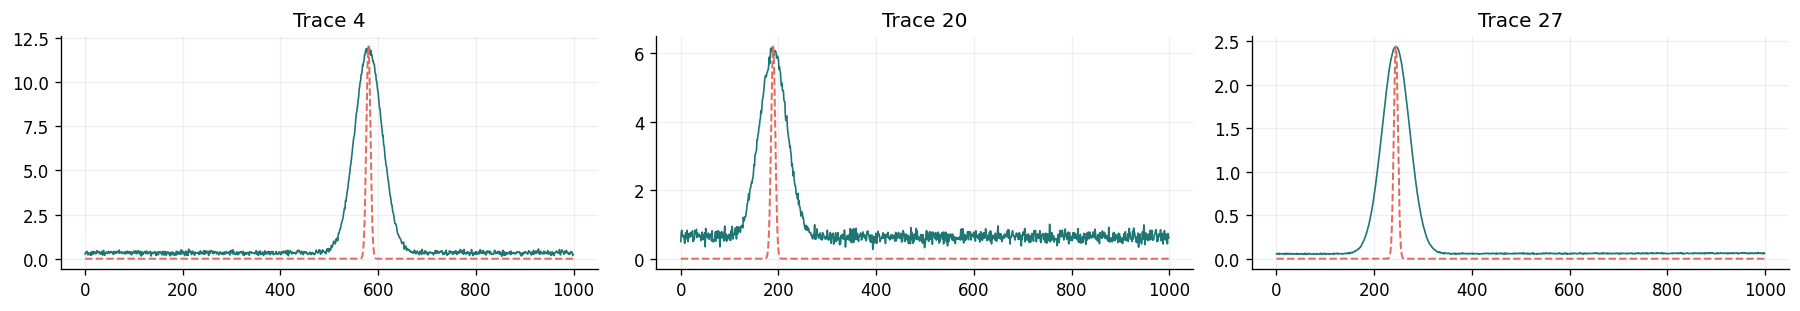

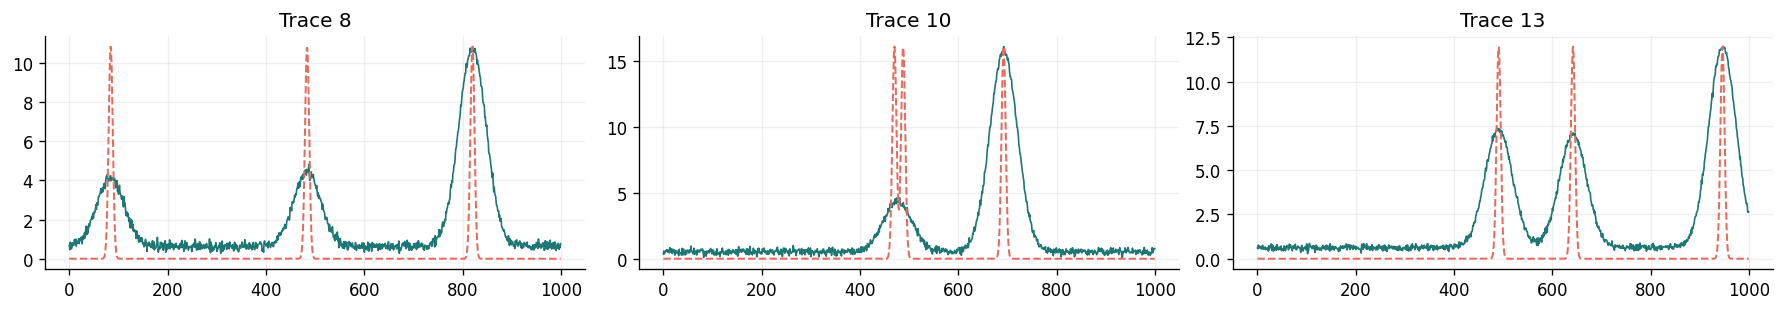

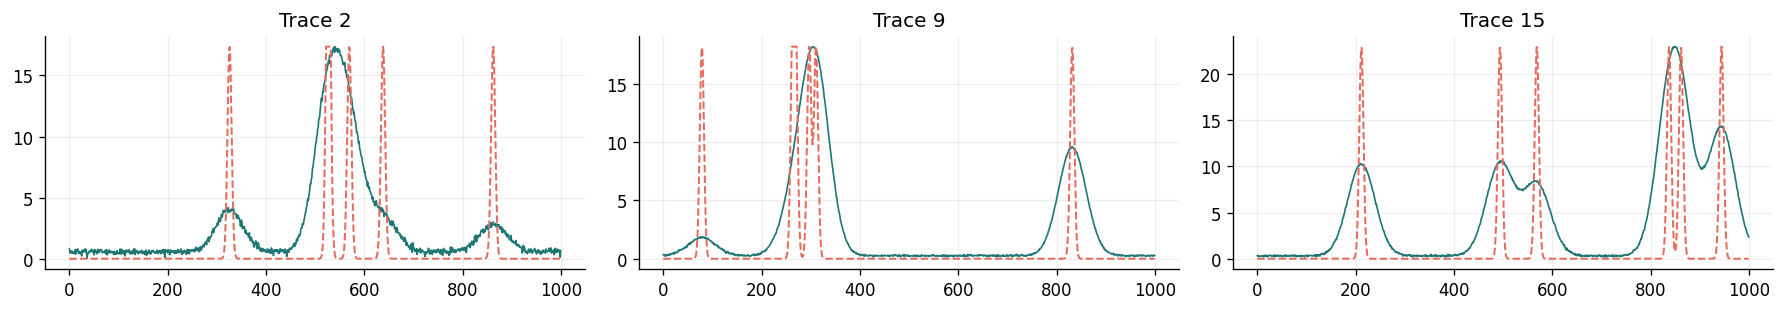

In [30]:
for event_count in (1, 3, 6):
    print(f"{event_count} events per trace")
    analysis.plot_density(
        event_count,
        number_of_samples=3,
        number_of_columns=3,
    )

## 5. Train the WaveNet

The class trains against narrow Gaussian localization targets rather than one-sample labels. Keras reserves the final `VALIDATION_FRACTION` of the deterministically shuffled dataset through `validation_split`; the class retains a matching view of those rows for threshold calibration.

In [33]:
training_config = TrainingConfig(
    epochs=30,
    batch_size=TRAIN_BATCH_SIZE,
    validation_split=VALIDATION_FRACTION,
    patience=2,
    learning_rate_factor=0.1,
    min_learning_rate=1e-6,
    seed=TRAIN_SEED,
    verbose=1,
)

if TRAIN_WAVENET:
    history = analysis.fit(training_config, save_name=None)
    wavenet.save(str(MODEL_DIRECTORY))
    print(f"Trained and saved WaveNet to {MODEL_DIRECTORY}")
else:
    history = None
    print(f"Loaded existing WaveNet from {MODEL_DIRECTORY}")

Epoch 1/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 24s 114ms/step - loss: 0.1092 - mae: 0.0083 - val_loss: 0.1092 - val_mae: 0.0072 - learning_rate: 0.0010
Epoch 2/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - loss: 0.1089 - mae: 0.0082 - val_loss: 0.1100 - val_mae: 0.0072 - learning_rate: 0.0010
Epoch 3/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 19s 97ms/step - loss: 0.1062 - mae: 0.0072 - val_loss: 0.1067 - val_mae: 0.0079 - learning_rate: 1.0000e-04
Epoch 4/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - loss: 0.1059 - mae: 0.0070 - val_loss: 0.1067 - val_mae: 0.0081 - learning_rate: 1.0000e-04
Epoch 5/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - loss: 0.1057 - mae: 0.0070 - val_loss: 0.1068 - val_mae: 0.0082 - learning_rate: 1.0000e-04
Epoch 6/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - loss: 0.1055 - mae: 0.0070 - val_loss: 0.1062 - val_mae: 0.0070 - learning_rate: 1.0000e-05
Epoch 7/30
198/198 ━━━━━━━━━━━━━━━━━━━━ 20s 101ms/step - loss: 0.1054 - mae: 0.0069 - val_loss: 0.1062 - val_mae: 0

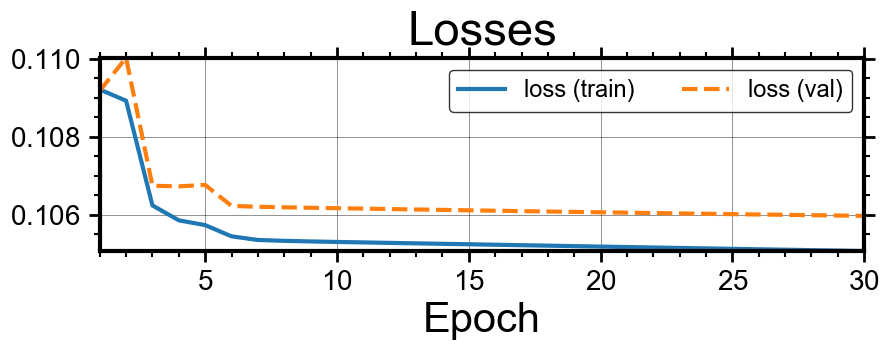

,loss,mae,val_loss,val_mae,learning_rate
25,0.105120,0.006785,0.106011,0.006902,0.00001
26,0.105109,0.006781,0.106002,0.006898,0.00001
27,0.105098,0.006777,0.105994,0.006893,0.00001
28,0.105087,0.006774,0.105985,0.006890,0.00001
29,0.105076,0.006769,0.105976,0.006885,0.00001


In [34]:
if history is None:
    print("Training history is only available after a new training run.")
else:
    history_frame = pd.DataFrame(history.history)
    training_history_figure = wavenet.plot_model_history(kind="loss")
    training_history_figure.tight_layout()
    training_history_figure.savefig(
        OUTPUT_DIR / "training_history.png", bbox_inches="tight"
    )
    display(history_frame.tail())

### Inspect predictions on the validation split

Overlay the normalized detector trace, reference target, and WaveNet output for six randomly selected held-out validation traces.

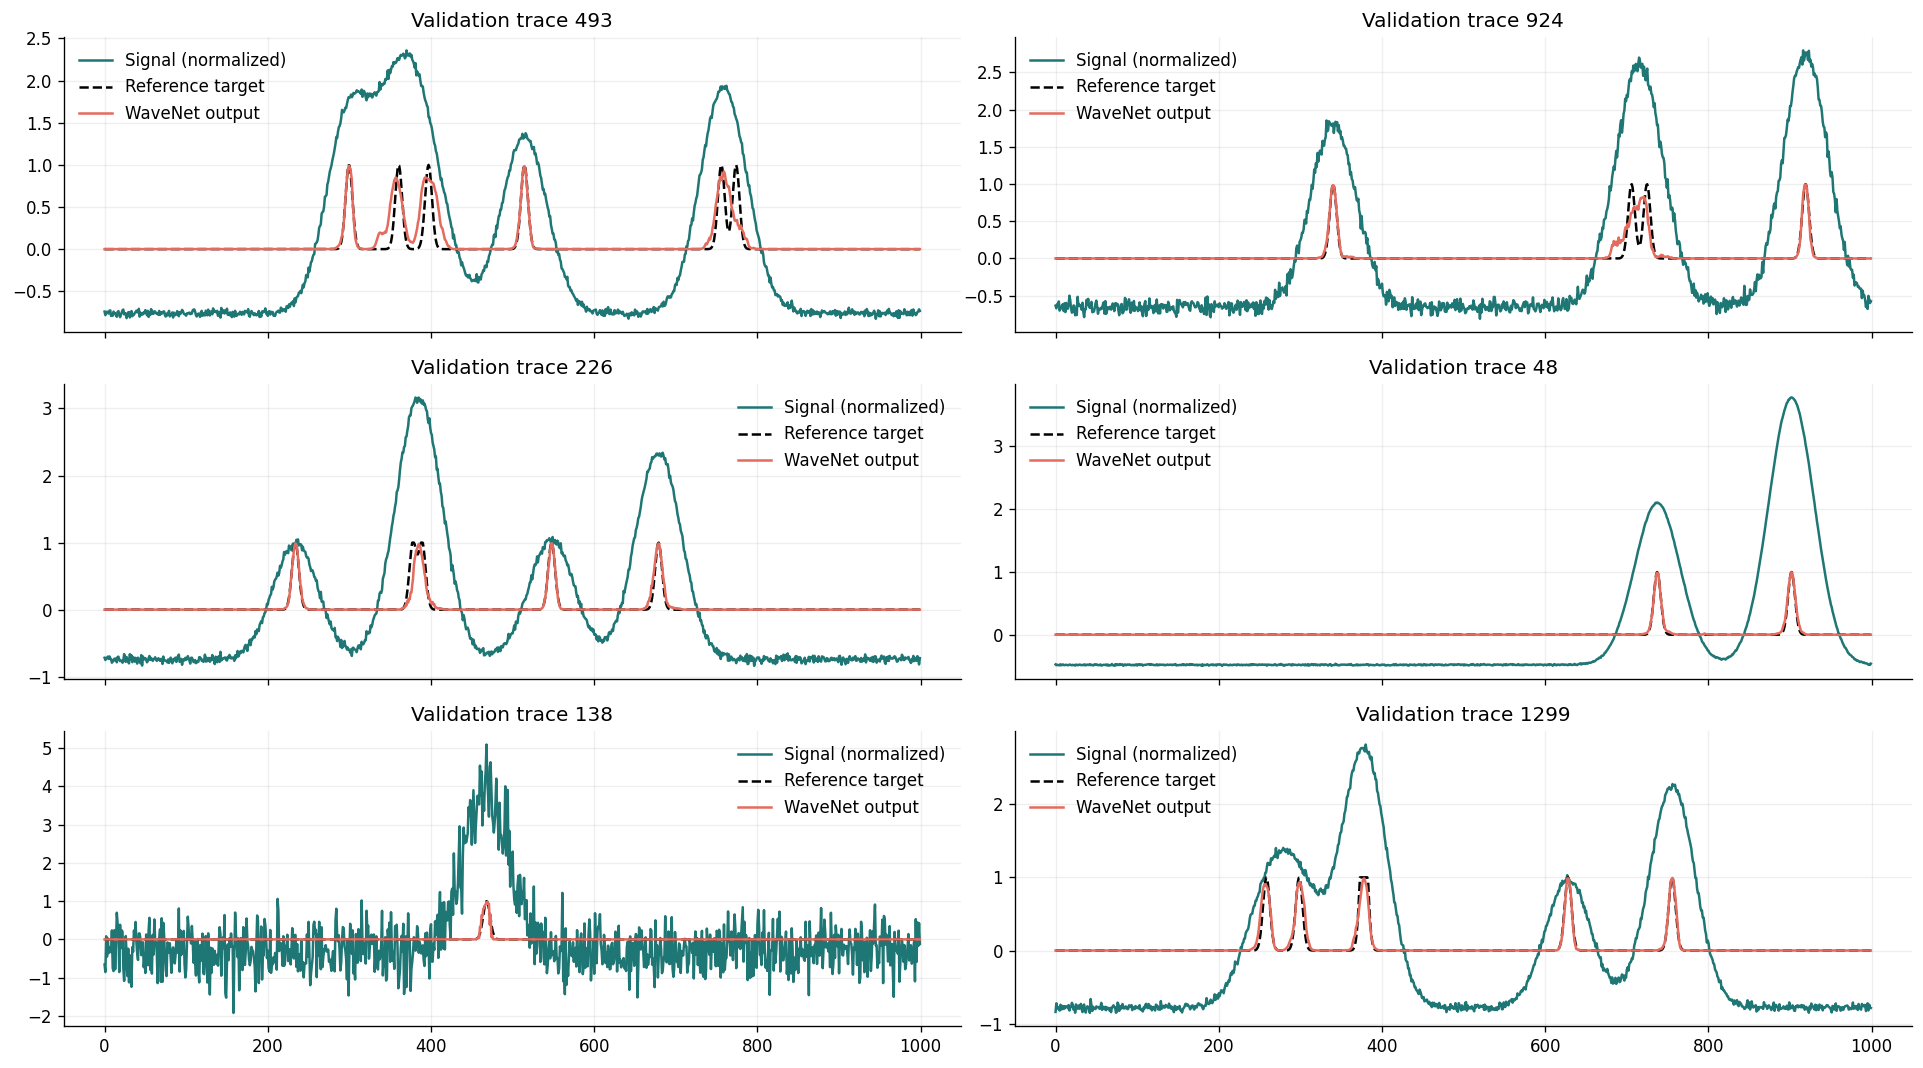

In [36]:
N_VALIDATION_PREVIEWS = 6
validation_dataset = analysis.validation_dataset
validation_signals = validation_dataset.get_normalized_signal("zscore")
validation_labels = analysis._targets(validation_dataset)

preview_count = min(N_VALIDATION_PREVIEWS, validation_dataset.n_samples)
preview_indices = np.random.default_rng().choice(
    validation_dataset.n_samples, size=preview_count, replace=False
)
preview_signals = np.take(validation_signals, preview_indices, axis=0)
preview_labels = np.take(validation_labels, preview_indices, axis=0)
preview_predictions = wavenet.model.predict(
    preview_signals[..., np.newaxis], verbose=0
)[..., 0]

validation_prediction_figure, axes = plt.subplots(
    nrows=3, ncols=2, figsize=(16, 9), squeeze=False, sharex=True
)
for axis, dataset_index, signal, label, prediction in zip(
    axes.ravel(), preview_indices, preview_signals,
    preview_labels, preview_predictions,
):
    axis.plot(signal, label="Signal (normalized)", color="#1f7775")
    axis.plot(
        label, label="Reference target", color="black", linestyle="--"
    )
    axis.plot(prediction, label="WaveNet output", color="#e46b5d")
    axis.set_title(f"Validation trace {dataset_index}")
    axis.grid(alpha=0.2)
    axis.legend(frameon=False)
for axis in axes.ravel()[preview_count:]:
    axis.set_visible(False)
validation_prediction_figure.tight_layout()
validation_prediction_figure.savefig(
    OUTPUT_DIR / "validation_prediction_examples.png", bbox_inches="tight"
)
plt.show()

### Calibrate the CNN operating threshold

Choose the probability threshold from event-level validation F1, using absolute count bias as the tie-breaker. The held-out test set is not used during calibration.

In [37]:
threshold_scan = analysis.calibrate_cnn_threshold()
print(f"Selected CNN threshold: {analysis.cnn_threshold:.2f}")
threshold_scan.sort_values("threshold")

Selected CNN threshold: 0.75


,threshold,precision,recall,f1,count_bias_percent,absolute_count_bias_percent
0,0.05,0.681535,0.923874,0.784414,32.015823,32.015823
1,0.10,0.760538,0.925801,0.835072,19.654008,19.654008
2,0.15,0.799917,0.925560,0.858164,14.675105,14.675105
3,0.20,0.831059,0.924356,0.875228,10.683544,10.683544
4,0.25,0.854914,0.924115,0.888169,7.921941,7.921941
5,0.30,0.875000,0.924115,0.898887,5.986287,5.986287
6,0.35,0.893731,0.923874,0.908552,4.360759,4.360759
7,0.40,0.907670,0.923633,0.915582,2.983122,2.983122
8,0.45,0.921211,0.923874,0.922540,1.854430,1.854430
9,0.50,0.930951,0.922428,0.926670,0.890295,0.890295


## 6. Inspect held-out data

These traces were generated from an independent seed and were not used for training or validation.

## 7. Evaluate both detectors

The classical baseline is intentionally simple: it subtracts each trace's median baseline, retains only threshold regions that persist for `CLASSICAL_DEBOUNCE_SAMPLES` consecutive samples, and positions each accepted event at that region's maximum. It performs no SciPy peak finding. The CNN branch thresholds the WaveNet output independently.

In [38]:
results = analysis.evaluate()
results

,method,scenario,level,precision,recall,count_bias_percent,timing_error_samples,amplitude_error,throughput_traces_per_second,n_traces
0,Classical baseline,event_density,1.0,0.800000,1.000000,25.000000,1.500000,0.554772,8212.616533,24
1,Classical baseline,event_density,2.0,0.760870,0.729167,-4.166667,1.428571,0.863385,4037.119264,24
2,Classical baseline,event_density,3.0,0.777778,0.680556,-12.500000,1.632653,0.809592,10060.083801,24
3,Classical baseline,event_density,4.0,0.750000,0.500000,-33.333333,1.583333,1.833863,6783.334488,24
4,Classical baseline,event_density,5.0,0.756757,0.466667,-38.333333,1.857143,1.215822,7633.488111,24
5,Classical baseline,event_density,6.0,0.682927,0.388889,-43.055556,2.196429,1.823127,11501.364637,24
6,DeepPeak WaveNet,event_density,1.0,1.000000,1.000000,0.000000,0.041667,0.454530,33.360274,24
7,DeepPeak WaveNet,event_density,2.0,1.000000,0.979167,-2.083333,0.234043,0.703013,33.802896,24
8,DeepPeak WaveNet,event_density,3.0,0.985915,0.972222,-1.388889,0.442857,1.453381,34.513861,24
9,DeepPeak WaveNet,event_density,4.0,0.976471,0.864583,-11.458333,0.530120,1.833923,34.461406,24


### Inspect one decision trace

Use `index="random"` or a specific integer. Change `event_count` to inspect any evaluated density. The raw trace is never smoothed.

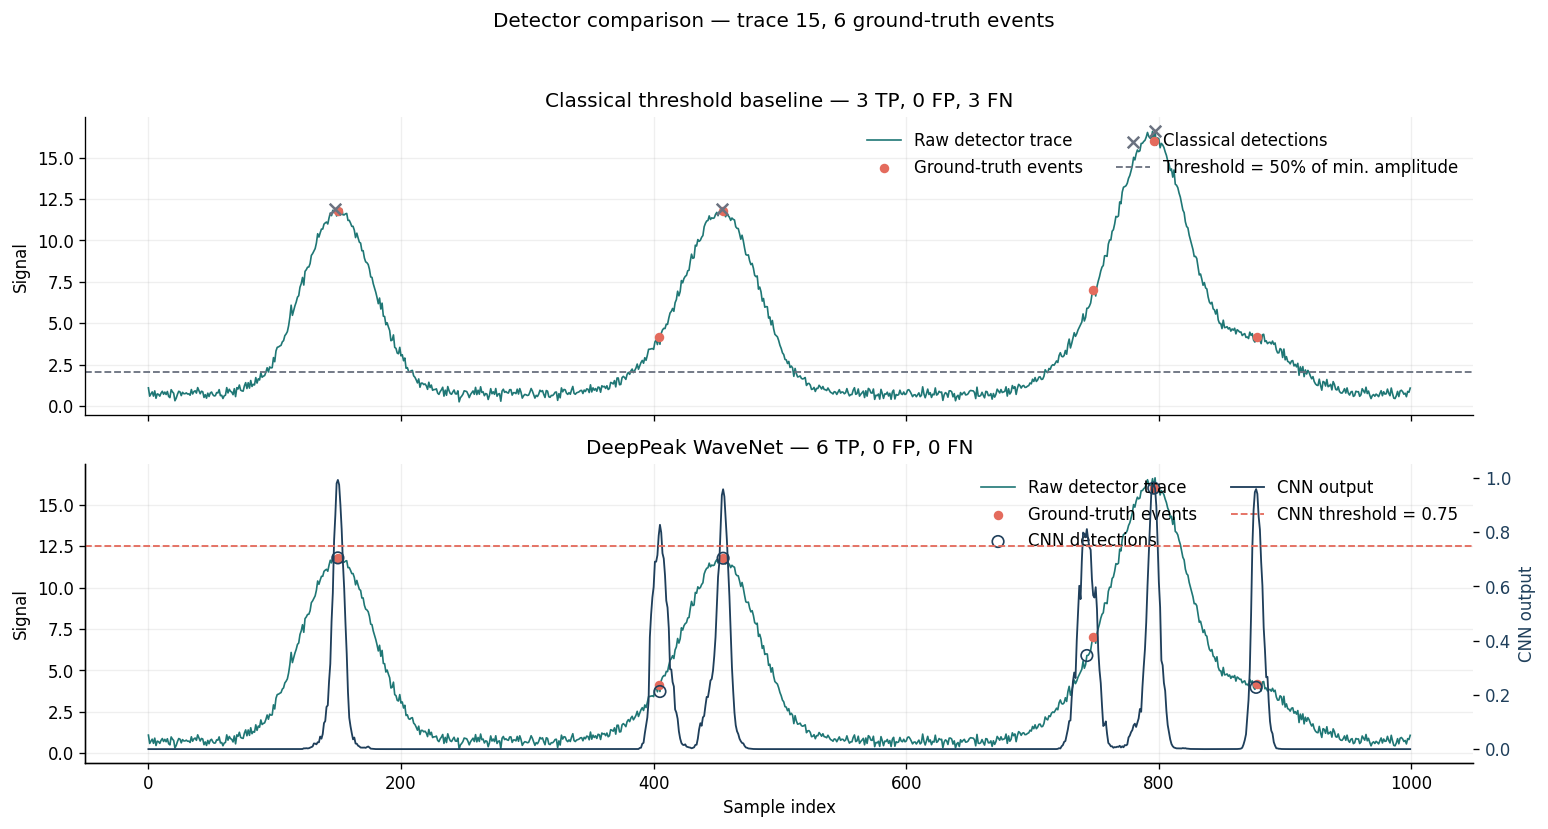

In [39]:
diagnostic_figure = analysis.plot_detector_comparison(
    # index=0,
    event_count=max(EVENT_COUNTS),
)

## 8. Presentation outputs

In [40]:
summary = analysis.summary()
summary

,precision,recall,count_bias_percent,timing_error_samples,amplitude_error,throughput_traces_per_second
method,,,,,,
Classical baseline,0.755,0.628,-17.731,1.700,1.183,8038.001
DeepPeak WaveNet,0.982,0.932,-5.081,0.482,1.555,34.162


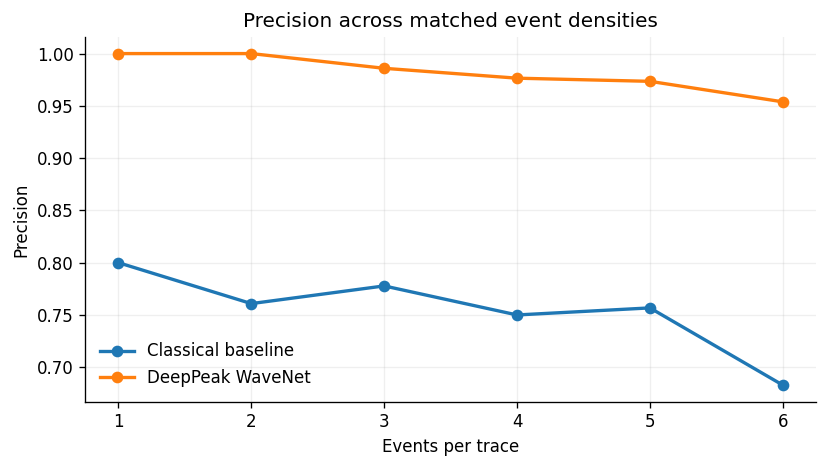

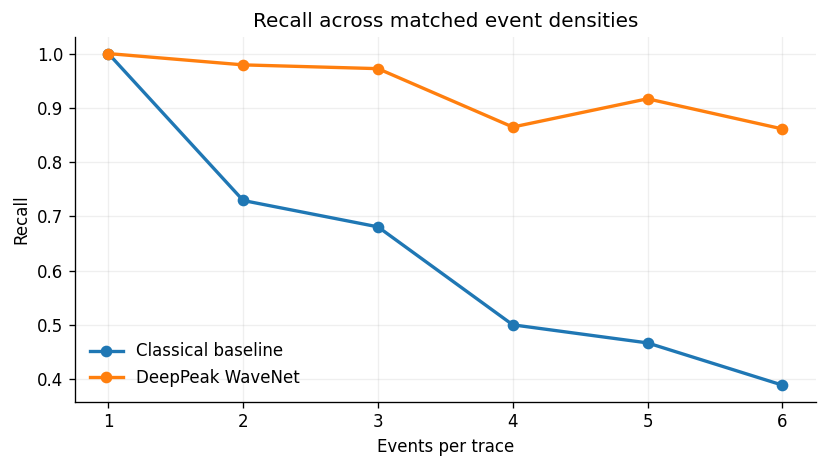

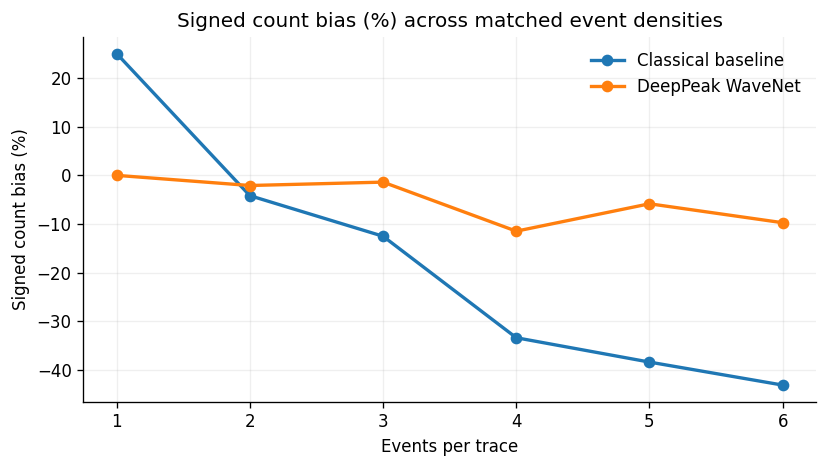

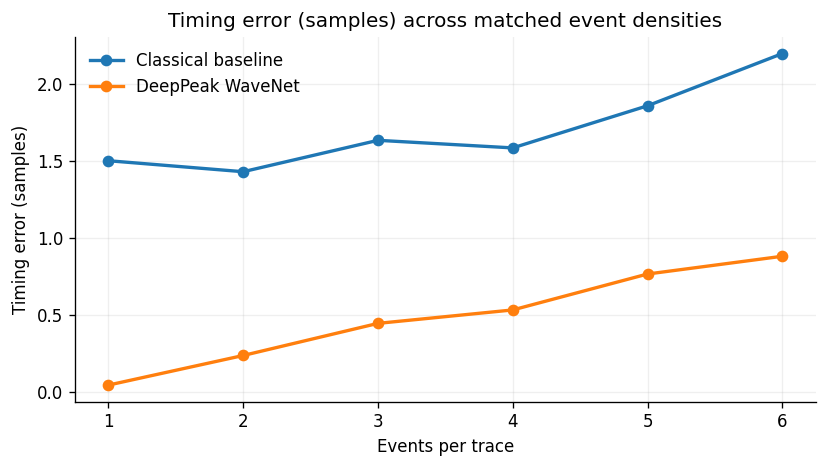

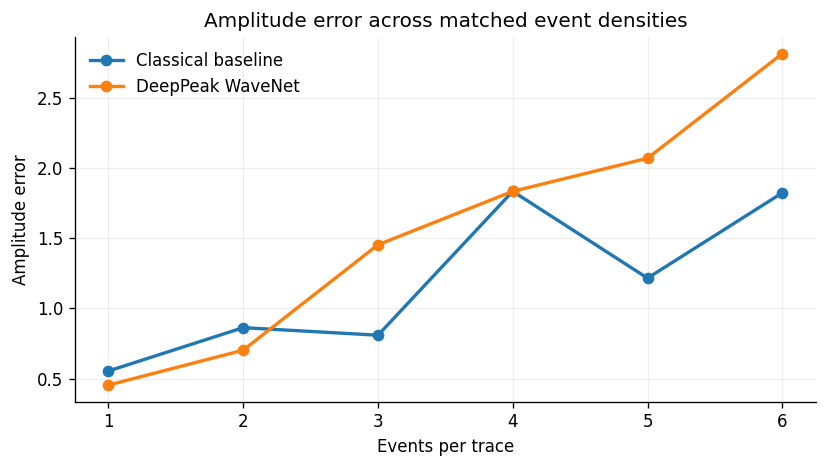

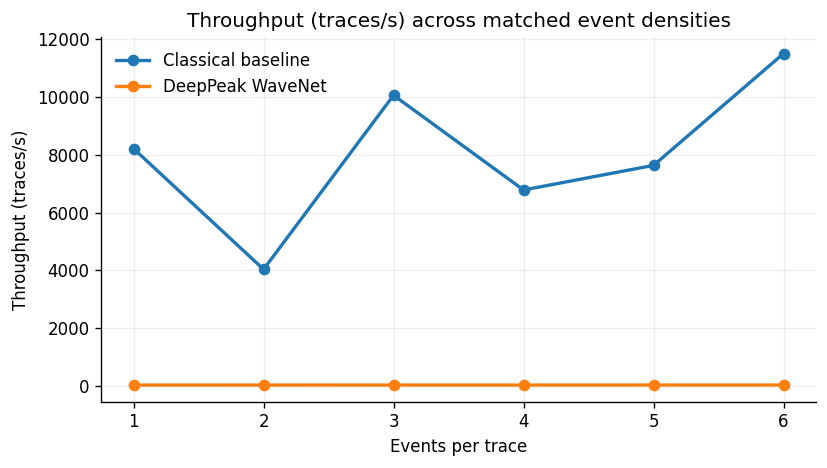

In [41]:
metric_figures = analysis.plot_metrics()

## Interpretation checklist

- **Precision / recall:** Does localization remain reliable as event density increases?
- **Count bias:** Is the signed bias near zero, without systematic over- or under-counting?
- **Timing error:** Are recovered event times within the matching tolerance?
- **Amplitude error:** Does amplitude fidelity improve relative to the classical branch?
- **Throughput:** Is speed reported together with the conditions under which it remains valid?

Only copy results produced after the training cell completes. Record the seeds, sample counts, epoch count, thresholds, and saved model directory with the figures.